# Importing Dependencies

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

# Defining Variables

$S_0$: Initial asset price

$\mu$: Mean return (drift component)

$\sigma$: Volatility of the diffusion process

$\lambda$: Jump intensity (controls rate of jumps)

$\mu_j$: Mean of log jump

$\sigma_j$: Standard deviation of log Jump

$T$: Time horizon

$n$: Number of time steps

$\Delta t$: Time increment for each step $\Delta t = \frac{T}{n}$

$k$: Expected relative jump size (compensation term) $k=e^{(\mu_j+\frac{1}{2} \sigma_j ^ 2)}-1$

$Z_{j,i}$: Standard normal variable driving diffusion process

$\Delta N_{j,i}$: Poisson random varable with parameter $\lambda \Delta t$, determines number of jumps during a specific time step

$L_{j,i} \left (Y \right)$: Log-jump size drawn from $L_{j,i}\sim \mathbf{N}(\mu_j,\sigma^2_j)$

In [2]:
S0 = 1
mu = 0.03
sigma = 0.2
lam = 1
mu_j = 0.05
sigma_j = 0.05
T = 1
n = 252
num_paths = 100

# Simulating Paths

**Discrete time model used for this simulation:**

$$S_{j,i+1} = S_{j,i}\exp \big[(\mu - \frac{1}{2}\sigma^2-\lambda k) \Delta t + \sigma \sqrt{\Delta t} Z_{j,i}+ \Delta N_{j,i} L_{j,i}\big]$$

Where $j\in[1,\text{num\_paths}]$ and $i\in[0,n-1]$

In [3]:
def simulate_jump_diffusion(S0,mu,sigma,lam,mu_j,sigma_j,n,num_paths,T):
  dt = T/n

  S = np.insert(np.zeros((n,num_paths),dtype=float),0,S0,axis=0)
  Z = np.random.normal(size=(n,num_paths))
  Y = np.random.normal(loc=mu_j,scale=sigma_j,size=(n,num_paths))
  dN = np.random.poisson(lam*dt,size=(n,num_paths))

  k = np.exp(mu_j+0.5*sigma_j**2)-1

  drift = (mu - 0.5 * sigma ** 2 - lam * k) * dt
  diffusion = lambda i: sigma * np.sqrt(dt) * Z[i]
  jump = lambda i: Y[i] * dN[i]

  for i in range(0,n):
    S[i+1] = S[i] * np.exp(drift + diffusion(i) + jump(i))

  return S

# Plotting Paths

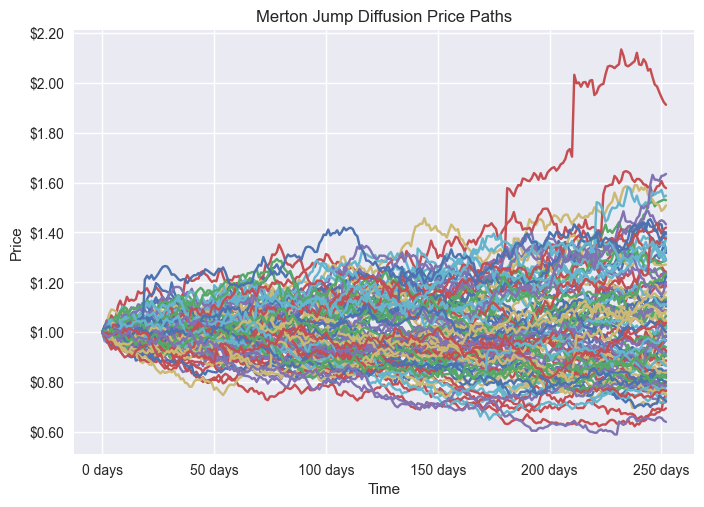

In [4]:
paths = simulate_jump_diffusion(S0,mu,sigma,lam,mu_j,sigma_j,n,num_paths,T)

plt.plot(paths)
plt.grid(True)
plt.xlabel("Time")
plt.ylabel("Price")
plt.title("Merton Jump Diffusion Price Paths")
plt.gca().yaxis.set_major_formatter("${x:,.2f}")
plt.gca().xaxis.set_major_formatter("{x:,.0f} days")
plt.show()